In [41]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
print('Running...')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# ignore deprecation warning
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

Running...


Last updated on 260205 for TR1-2026

# Your team
* Juninho Chandra
* Hu ZeDong

# Credit Member Statement 
This form is to recognise individual member contributions, reducing member disputes and facilitating collaboration within group. Please have a discussion on this within your group and insert this credit member statement here.

Juninho Chandra: 
- This main notebook on part 2, 3 and 7
- https://www.kaggle.com/code/juninhochandra/cp3403-5634-project-v2025a-classification on Task 5
- https://www.kaggle.com/code/juninhochandra/cp3403-5634-project-v2025a-clustering on Task 6

Hu ZeDong:
- This main notebook on part 1
- https://www.kaggle.com/code/asuka520/cp3403-5634-project-v2025a-arm on Task 4

# Task 1: Dataset

My first reason is obviously meeting the prerequisite of the assignment, second of all,
Traffic accidents are a key area of study for understanding public safety and factors influencing road safety in the US.
It provides us with meaningful column such as accident severity, location, weather, time of day, etc.
It will be interesting how each of these variables relate to each other and reveal hidden pattern.
From this dataset, I hope I can identify high-risk factors contributing to the accidents.

In [42]:
# import dataset(s) into pandas and print samples.

fpath = '/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv'
df = pd.read_csv(fpath, nrows=1000000)
# Print sample rows
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [43]:
# Print all column names
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

# Task 2: business scenarios

List one or more possible questions you would like to investigate using your dataset. You may start this project with one set of questions but (after exploring the dataset) finish with a new set of questions and answers.

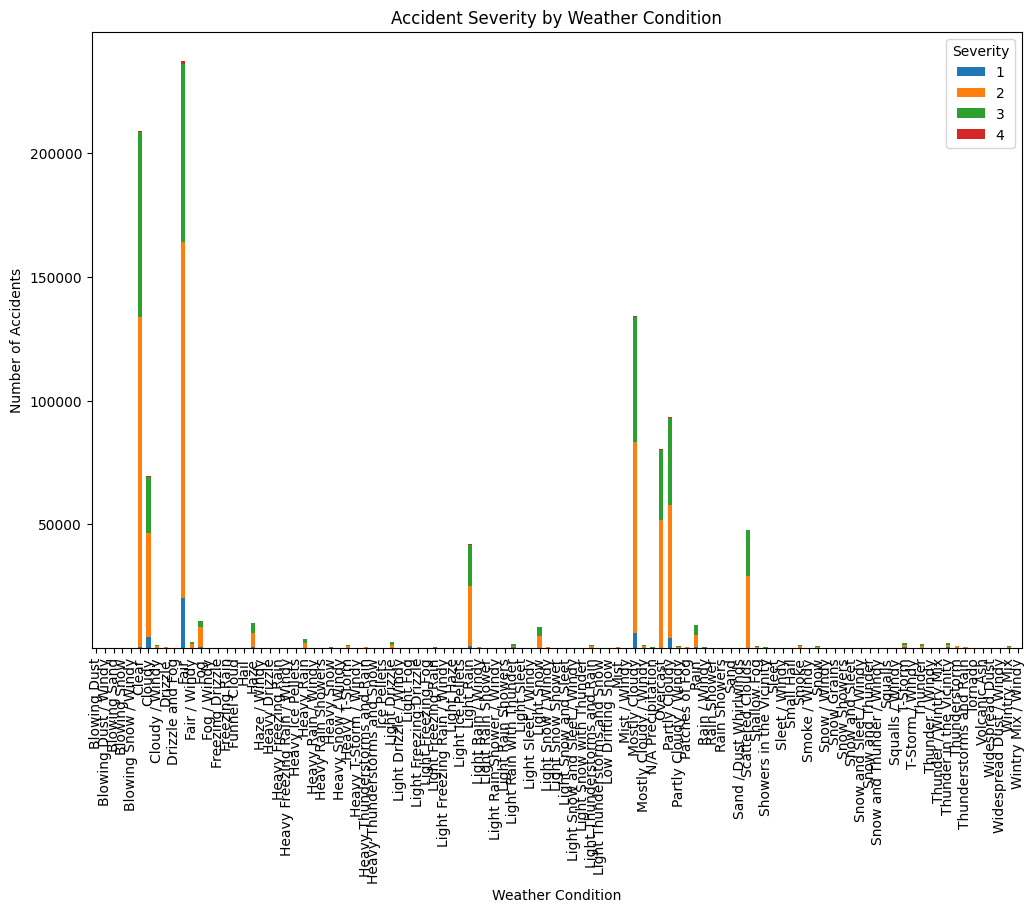

In [44]:
# Question 1: What weather conditions are most associated with the most severe accidents?

# grouping the dataframe weather_condition and severity counts, and fill any missing value with 0
weather_severity = df.groupby('Weather_Condition')['Severity'].value_counts().unstack().fillna(0)

# Visualize it as a bar plot.
import matplotlib.pyplot as plt # matplotlib module for plotting graphs
weather_severity.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Accident Severity by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=90)
plt.show()

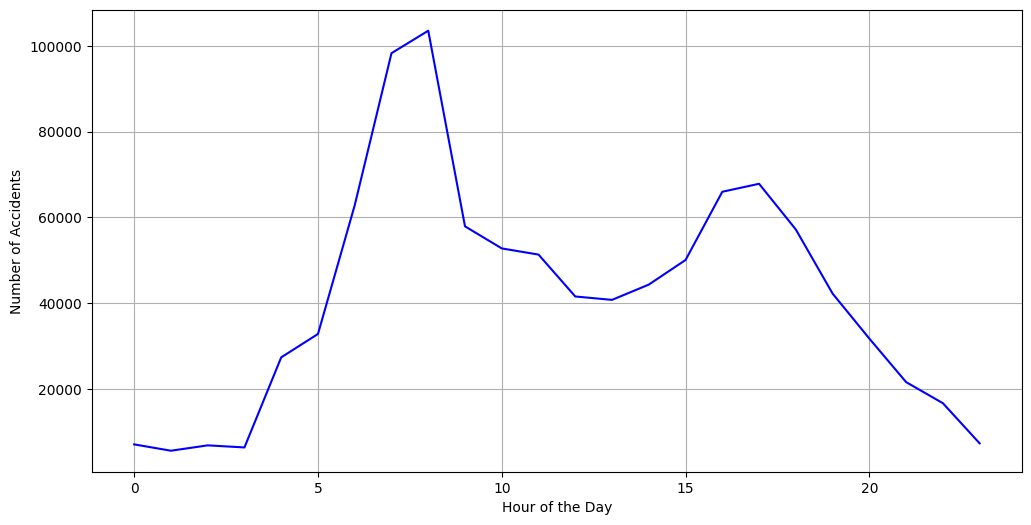

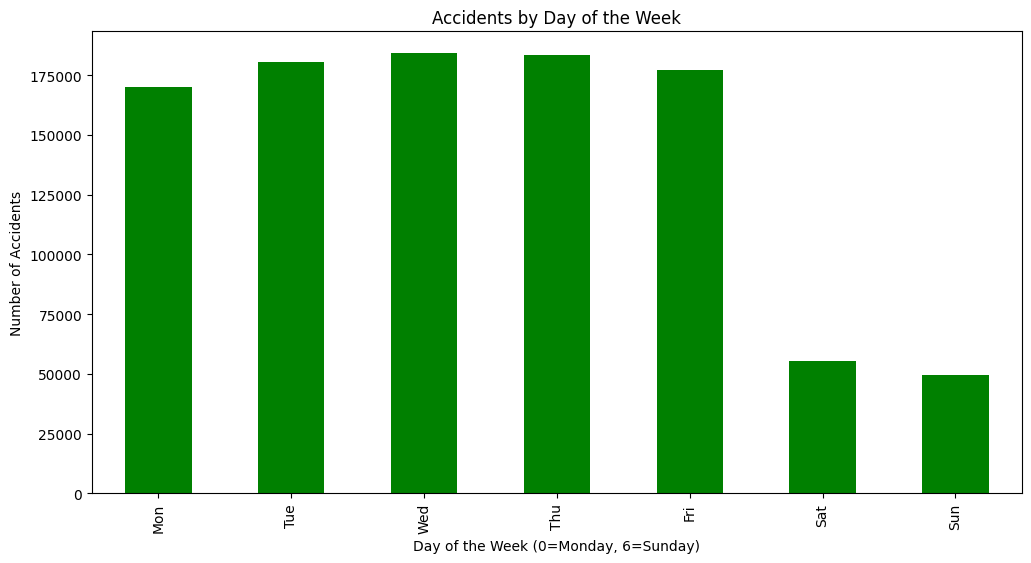

In [45]:
# Question 2: How do accident vary by time of day or data of the week?

# convert 'Start_Time' to datetime format and extract the time and weekday
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce', utc=True)
df['Hour'] = df['Start_Time'].dt.hour
df['Weekday'] = df['Start_Time'].dt.weekday # Monday = 0, Sunday = 6

# accidents by hour of the day, plot a line bar
accidents_by_hour = df.groupby('Hour')['Severity'].count()
accidents_by_hour.plot(kind='line', figsize=(12,6), color='blue')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.show()

# accidents by day of the week
accidents_by_weekday = df.groupby('Weekday')['Severity'].count()
accidents_by_weekday.plot(kind='bar', figsize=(12, 6), color='green')
plt.title('Accidents by Day of the Week')
plt.xlabel('Day of the Week (0=Monday, 6=Sunday)')
plt.ylabel('Number of Accidents')
plt.xticks(ticks=range(7), labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()

# Tast-3: preprocessing

In [46]:
# reset the csv file
df = pd.read_csv(fpath, nrows=1000000)

# print all column names
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

### Initial inspection

See any missing values, identify data types, and detect useless columns.

In [47]:
print(df.shape)
df.info()
df.describe()

(1000000, 46)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 46 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   ID                     1000000 non-null  object 
 1   Source                 1000000 non-null  object 
 2   Severity               1000000 non-null  int64  
 3   Start_Time             1000000 non-null  object 
 4   End_Time               1000000 non-null  object 
 5   Start_Lat              1000000 non-null  float64
 6   Start_Lng              1000000 non-null  float64
 7   End_Lat                0 non-null        float64
 8   End_Lng                0 non-null        float64
 9   Distance(mi)           1000000 non-null  float64
 10  Description            999999 non-null   object 
 11  Street                 998288 non-null   object 
 12  City                   999972 non-null   object 
 13  County                 1000000 non-null  object 
 14  State

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,1000000.000000,1000000.000000,1000000.000000,0.0,0.0,1000000.000000,984702.000000,539411.000000,983447.000000,987624.000000,981069.000000,899602.000000,524684.000000
mean,2.320200,36.059323,-94.753951,NaN,NaN,0.167486,64.619012,59.439159,66.026522,29.693616,9.173668,7.767917,0.013259
std,0.548478,4.906870,17.391816,NaN,NaN,1.427785,17.450734,21.930704,21.890455,0.792132,2.259461,5.408117,0.203154
min,1.000000,24.554800,-124.497414,NaN,NaN,0.000000,-77.800000,-50.000000,1.000000,0.120000,0.000000,0.000000,0.000000
25%,2.000000,32.925510,-117.370224,NaN,NaN,0.000000,54.000000,43.000000,50.000000,29.560000,10.000000,4.600000,0.000000
50%,2.000000,35.258339,-87.957626,NaN,NaN,0.000000,66.900000,64.000000,68.000000,29.910000,10.000000,7.000000,0.000000
75%,3.000000,40.113201,-80.919167,NaN,NaN,0.010000,77.000000,76.000000,84.000000,30.050000,10.000000,10.400000,0.000000
max,4.000000,48.998085,-68.160789,NaN,NaN,336.570007,196.000000,196.000000,100.000000,58.100000,111.000000,822.800000,36.470000


### Handle missing values

Check missing values.

In [48]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

End_Lng                  1000000
End_Lat                  1000000
Precipitation(in)         475316
Wind_Chill(F)             460589
Wind_Speed(mph)           100398
Visibility(mi)             18931
Weather_Condition          18211
Humidity(%)                16553
Temperature(F)             15298
Wind_Direction             13570
Pressure(in)               12376
Weather_Timestamp           9927
Street                      1712
Civil_Twilight              1636
Astronomical_Twilight       1636
Nautical_Twilight           1636
Sunrise_Sunset              1636
Airport_Code                1432
Timezone                     451
Zipcode                      136
dtype: int64


Drop columns with too many missing values, 50% missing.

In [49]:
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)

Handle moderate missing values using their median, to reduce effect of outliers

In [50]:
cols_median = [
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
    'Visibility(mi)', 'Wind_Speed(mph)'
]

for col in cols_median:
    df[col] = df[col].fillna(df[col].median())

# Too many missing values suggests that the column is not reliable for creating models
df = df.drop(columns=['Wind_Chill(F)', 'Precipitation(in)'])

# Final cleanup
df = df.fillna(0)

### Remove irrelevant columns

The dataset has many columns that we don't need, since it's text heavy (useless for machine learning), and too specific, which adds noise.

In [51]:
drop_cols = [
    'ID', 'Source', 'Description', 'Street', 'County', 
    'Zipcode', 'Country', 'Timezone', 'Airport_Code'
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

### Convert datetime features.

Format time related columns into datetime style values.

In [52]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

df['Year'] = df['Start_Time'].dt.year
df['Month'] = df['Start_Time'].dt.month
df['Day'] = df['Start_Time'].dt.day
df['Hour'] = df['Start_Time'].dt.hour
df['Weekday'] = df['Start_Time'].dt.weekday

Then drop the original column.

In [53]:
df = df.drop(columns=['Start_Time', 'End_Time'], errors='ignore')

### Encode categorical variables.

Label encoding.

In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

### Feature scaling

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('Severity', errors='ignore')  # don't scale target

df[num_cols] = scaler.fit_transform(df[num_cols])

We will most unlikely deal with outliers since the data is quite heavy.

### Final check

In [56]:
print(df.isnull().sum().sum())  # should be 0
print(df.shape)
df.head()

0
(1000000, 36)


,Severity,Start_Lat,Start_Lng,Distance(mi),City,State,Weather_Timestamp,Temperature(F),Humidity(%),Pressure(in),...,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Year,Month,Day,Hour,Weekday
0,3,0.775612,0.614958,-0.110301,-0.907403,0.838355,-1.750429,-1.602513,1.148818,-0.020689,...,False,1.631919,1.871326,2.199076,2.567543,2016,2,8,5,0
1,2,0.788433,0.685539,-0.110301,0.959628,0.838355,-1.750445,-1.544773,1.563374,-0.058781,...,False,1.631919,1.871326,2.199076,-0.378418,2016,2,8,6,0
2,2,0.612168,0.616459,-0.110301,1.768929,0.838355,-1.750413,-1.654479,1.563374,-0.033386,...,False,1.631919,1.871326,-0.444340,-0.378418,2016,2,8,6,0
3,3,0.751687,0.606514,-0.110301,-0.907403,0.838355,-1.750398,-1.706445,1.379127,-0.071478,...,False,1.631919,-0.524345,-0.444340,-0.378418,2016,2,8,7,0
4,2,0.727238,0.607504,-0.110301,-0.907403,0.838355,-1.750350,-1.654479,1.056695,-0.058781,...,False,-0.602763,-0.524345,-0.444340,-0.378418,2016,2,8,7,0


In [57]:
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


# Task-4: ARM

### Create bins

In [58]:
df_arm = df.copy()

# Convert Hour into categories
df_arm['TimeOfDay'] = pd.cut(
    df_arm['Hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening'],
    include_lowest=True
)

# Convert Severity into string (for ARM)
df_arm['Severity'] = df_arm['Severity'].astype(str)

# Example: simplify some features
df_arm['High_Humidity'] = (df_arm['Humidity(%)'] > 0).astype(str)
df_arm['Low_Visibility'] = (df_arm['Visibility(mi)'] < 0).astype(str)

### Select features for ARM

In [59]:
cols_arm = ['Severity', 'TimeOfDay', 'High_Humidity', 'Low_Visibility']
df_arm = df_arm[cols_arm]

### One-hot encoding

In [60]:
df_encoded = pd.get_dummies(df_arm)

### Install mlxtend

In [61]:
!pip install mlxtend

## Apply Apriori

In [62]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    df_encoded,
    min_support=0.05,
    use_colnames=True
)

### Generate rules

In [63]:
rules_apriori = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

rules_apriori.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
59,"(Low_Visibility_True, TimeOfDay_Morning, Sever...",(High_Humidity_True),0.056885,0.532198,0.051406,0.903683,1.698020,0.021132,4.856893,0.435873
60,"(TimeOfDay_Afternoon, Low_Visibility_False, Se...",(High_Humidity_False),0.164503,0.467802,0.129892,0.789603,1.687899,0.052937,2.529490,0.487791
45,"(Low_Visibility_True, TimeOfDay_Morning)",(High_Humidity_True),0.086539,0.532198,0.077586,0.896544,1.684606,0.031530,4.521738,0.444890
47,"(TimeOfDay_Afternoon, Low_Visibility_False)",(High_Humidity_False),0.288191,0.467802,0.227092,0.787991,1.684455,0.092276,2.510265,0.570850
34,"(Low_Visibility_True, Severity_2)",(High_Humidity_True),0.111018,0.532198,0.099077,0.892441,1.676896,0.039993,4.349254,0.454070
64,"(TimeOfDay_Afternoon, Severity_3, Low_Visibili...",(High_Humidity_False),0.115399,0.467802,0.090155,0.781246,1.670035,0.036171,2.432860,0.453549
16,(Low_Visibility_True),(High_Humidity_True),0.178760,0.532198,0.158718,0.887883,1.668332,0.063582,4.172452,0.487798
40,"(Severity_3, Low_Visibility_True)",(High_Humidity_True),0.062057,0.532198,0.054393,0.876501,1.646945,0.021366,3.787890,0.418805
18,"(TimeOfDay_Night, Severity_2)",(High_Humidity_True),0.092979,0.532198,0.078193,0.840975,1.580192,0.028710,2.941686,0.404804
7,(TimeOfDay_Night),(High_Humidity_True),0.148890,0.532198,0.124930,0.839076,1.576623,0.045691,2.906972,0.429713


## Apply FP-Growth

In [64]:
from mlxtend.frequent_patterns import fpgrowth

frequent_fp = fpgrowth(
    df_encoded,
    min_support=0.05,
    use_colnames=True
)

### Generate rules

In [65]:
rules_fp = association_rules(
    frequent_fp,
    metric="confidence",
    min_threshold=0.6
)

rules_fp.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
41,"(Low_Visibility_True, TimeOfDay_Morning, Sever...",(High_Humidity_True),0.056885,0.532198,0.051406,0.903683,1.698020,0.021132,4.856893,0.435873
49,"(TimeOfDay_Afternoon, Low_Visibility_False, Se...",(High_Humidity_False),0.164503,0.467802,0.129892,0.789603,1.687899,0.052937,2.529490,0.487791
38,"(Low_Visibility_True, TimeOfDay_Morning)",(High_Humidity_True),0.086539,0.532198,0.077586,0.896544,1.684606,0.031530,4.521738,0.444890
54,"(TimeOfDay_Afternoon, Low_Visibility_False)",(High_Humidity_False),0.288191,0.467802,0.227092,0.787991,1.684455,0.092276,2.510265,0.570850
44,"(Low_Visibility_True, Severity_2)",(High_Humidity_True),0.111018,0.532198,0.099077,0.892441,1.676896,0.039993,4.349254,0.454070
59,"(TimeOfDay_Afternoon, Severity_3, Low_Visibili...",(High_Humidity_False),0.115399,0.467802,0.090155,0.781246,1.670035,0.036171,2.432860,0.453549
36,(Low_Visibility_True),(High_Humidity_True),0.178760,0.532198,0.158718,0.887883,1.668332,0.063582,4.172452,0.487798
42,"(Severity_3, Low_Visibility_True)",(High_Humidity_True),0.062057,0.532198,0.054393,0.876501,1.646945,0.021366,3.787890,0.418805
14,"(TimeOfDay_Night, Severity_2)",(High_Humidity_True),0.092979,0.532198,0.078193,0.840975,1.580192,0.028710,2.941686,0.404804
8,(TimeOfDay_Night),(High_Humidity_True),0.148890,0.532198,0.124930,0.839076,1.576623,0.045691,2.906972,0.429713


Apriori identifies frequent itemsets by expanding combinations iteratively and pruning those below the threshold

FP-Growth is a more efficient alternative to Apriori that avoids candidate generation by utilizing a tree-based structure

FP-Growth performed faster than Apriori while producing similar association rules, making it more suitable for large datasets.

# Task-5: Classification

https://www.kaggle.com/code/juninhochandra/cp3403-5634-project-v2025a-classification#Classification

We will be using K-Nearest Neighbour and Random Forest

### Define features and target

In [66]:
X = df.drop('Severity', axis=1)
y = df['Severity']

### Train test split

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### K-Nearest Neighbours (KNN)

In [68]:
# Train model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5) # 5 neighbours
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.66219
              precision    recall  f1-score   support

           1       0.55      0.67      0.61      7767
           2       0.72      0.77      0.74    121042
           3       0.56      0.48      0.52     70544
           4       0.39      0.03      0.06       647

    accuracy                           0.66    200000
   macro avg       0.56      0.49      0.48    200000
weighted avg       0.65      0.66      0.66    200000



### Random Forest (R Classification)

In [69]:
# Train model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.763365
              precision    recall  f1-score   support

           1       0.68      0.72      0.70      7767
           2       0.79      0.85      0.82    121042
           3       0.71      0.63      0.67     70544
           4       1.00      0.01      0.01       647

    accuracy                           0.76    200000
   macro avg       0.80      0.55      0.55    200000
weighted avg       0.76      0.76      0.76    200000



### Confusion Matrix

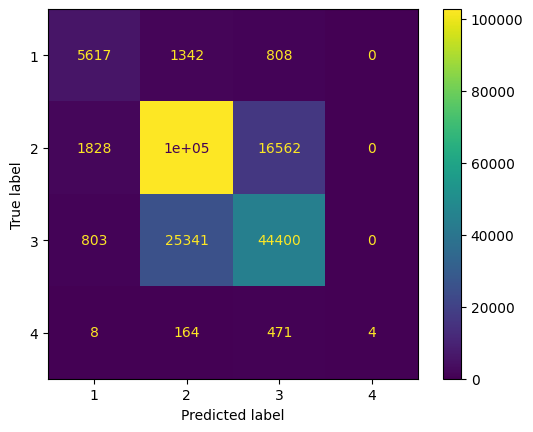

In [70]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

K-Nearest Neighbours classifies data based on similarity to nearby instances. It is simple but computationally expensive for large datasets.

Random Forest is a learning method that combines multiple decision trees to improve accuracy and reduce overfitting, quite useful for heavy datasets.

Random Forest outperforms KNN in accuracy due to its ability to handle large datasets and complex feature interactions more effectively.

# Task-6: Clustering

https://www.kaggle.com/code/juninhochandra/cp3403-5634-project-v2025a-clustering#Clustering

We will be using K-Means Clustering and DBScan

### Sampling data

Clustering on 1M rows will crash the kernel

In [71]:
df_cluster = df.sample(100000, random_state=42)

### Prepare data for clustering

In [72]:
X_cluster = df_cluster.drop('Severity', axis=1)

### K-Means Clustering

Find the optimal number of clusters (elbow method)

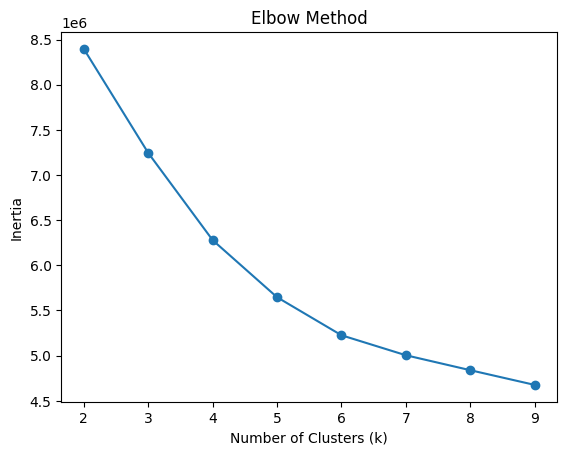

In [73]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Apply K-Means

In [74]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_cluster)

df_cluster['KMeans_Cluster'] = clusters_kmeans

Analyze clusters

In [75]:
df_cluster['KMeans_Cluster'].value_counts()

KMeans_Cluster
1    27518
0    26380
2    23737
3    22365
Name: count, dtype: int64

Visualize clusters

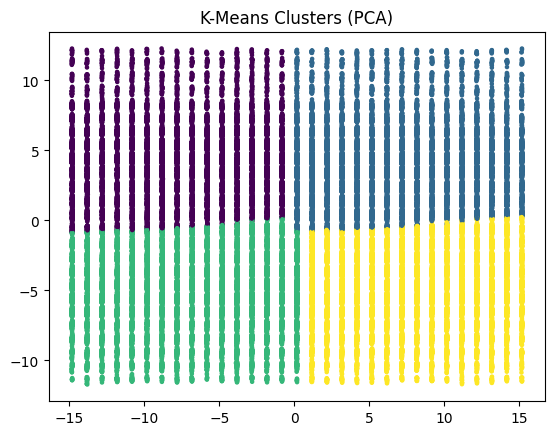

In [76]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans, s=5)
plt.title("K-Means Clusters (PCA)")
plt.show()

### DBScan

Apply DBScan

In [77]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.5, min_samples=10)
clusters_dbscan = dbscan.fit_predict(X_cluster)

df_cluster['DBSCAN_Cluster'] = clusters_dbscan

Analyze DBScan results

In [78]:
import numpy as np

print("Unique clusters:", np.unique(clusters_dbscan))
print("Cluster counts:\n", pd.Series(clusters_dbscan).value_counts())

Unique clusters: [ -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160
 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178
 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196
 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214
 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232
 233 234 235 236 237 238 239 240 2

Visualize DBScan

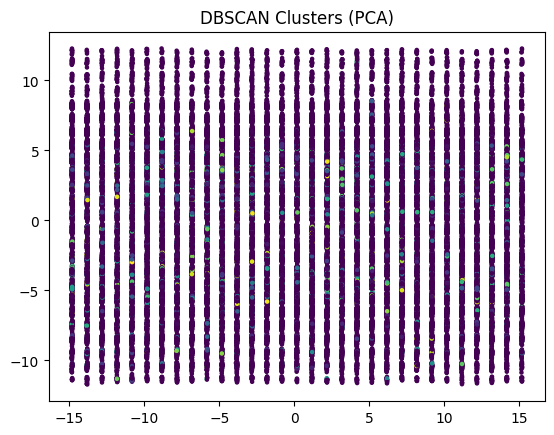

In [79]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_dbscan, s=5)
plt.title("DBSCAN Clusters (PCA)")
plt.show()

K-Means clustering partitions the dataset into k groups based on feature similarity. The optimal number of clusters was determined using the elbow method.

DBScan identifies clusters based on density and is capable of detecting noises, it does not require specifying the number of clusters in advance.

K-Means produced well defined clusters but required specifying k, which is 4 in out case. DBScan was able to detect noise and arbitrary-shaped clusters, however it ended up with uneven clusters and sensitive to parameter selection

# Task-7: Project specific and final results

1. Weather Conditions & Accident Severity
Key findings from Apriori and FP-Growth results suggests that
- (Low Visibility + Morning + Severity 2/3) -> High Humidity
- (Low Visibility) -> High Humidity (confidence ≈ 0.88-0.9, lift ≈ 1.66-1.69)
- (Night) -> High Humidity (confidence 0.89)

This results strongly indicate that Low visibility and high humidity are the most consistent weather conditions associated with accidents. When low visibility occurs, high humidity is likely to be present as well.

The critical insight is that weather conditions that reduce visibility, such as fog, rain, and humidity significantly increases the chance of an accident likelihood and severity.

From the random forest, it reports 76% accuracy, which reinforces weather features (humidity, visibility) are strong candidate as predictors for accident severity.

2. Time-Based Accident Patterns
Key findings from ARM results suggests that:
- (Night) -> High Humidity (confidence ≈ 0.84)
- (Morning + Low Visibility) -> High Humidity
- (Afternoon + Good Visibility) -> Low Humidity

From this, accident conditions vary significantly accross time of day, more dangerous conditions occur during night/early morning (high humidity and lower visibility), and less during afternoon (lower humidity and better visibility).

In short, accidents are more likely to happen under hazardous environmental conditions, such as high humidity and lower visibility.

3. Classification Insights for predicting Severity
Random Forest significantly outperforms KNN (66% < 76%), the accuracy also indicates that the data has non-linear relationships, and weather + time variables matter a lot.

One important thing to note is that Severity of the value 4 has low recall (0.01), meaning it is difficult to predict.

To summarize, the dataset is imbalanced, making extreme accident severity difficult to model accurately.

4. Clustering Insights
K-Means produced 4 balanced clusters, which suggests the dataset naturally groups into distinct accident patterns. DBScan on the other hand produces hundreds of large noise clusters.

It can be interpreted that the accident data is highly irregular and inseparable by density.

In the end, accident patterns are complex and do not form clear-density based clusters, indicating high variability in real world-conditions.

5. Association rule mining insights
Both Apriori and FP-Growth produced identical top rules, which confirms that the discovered patterns are stable and reliable

The patterns that plays a major role are:
- Low visibility -> high humidity
- Night/morning -> poor weather conditions
- Weather conditions strongly influence accident severity.

In conclusion, accident severity is not driven by a single factor, but by the interaction between weather conditions and time of day.